In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

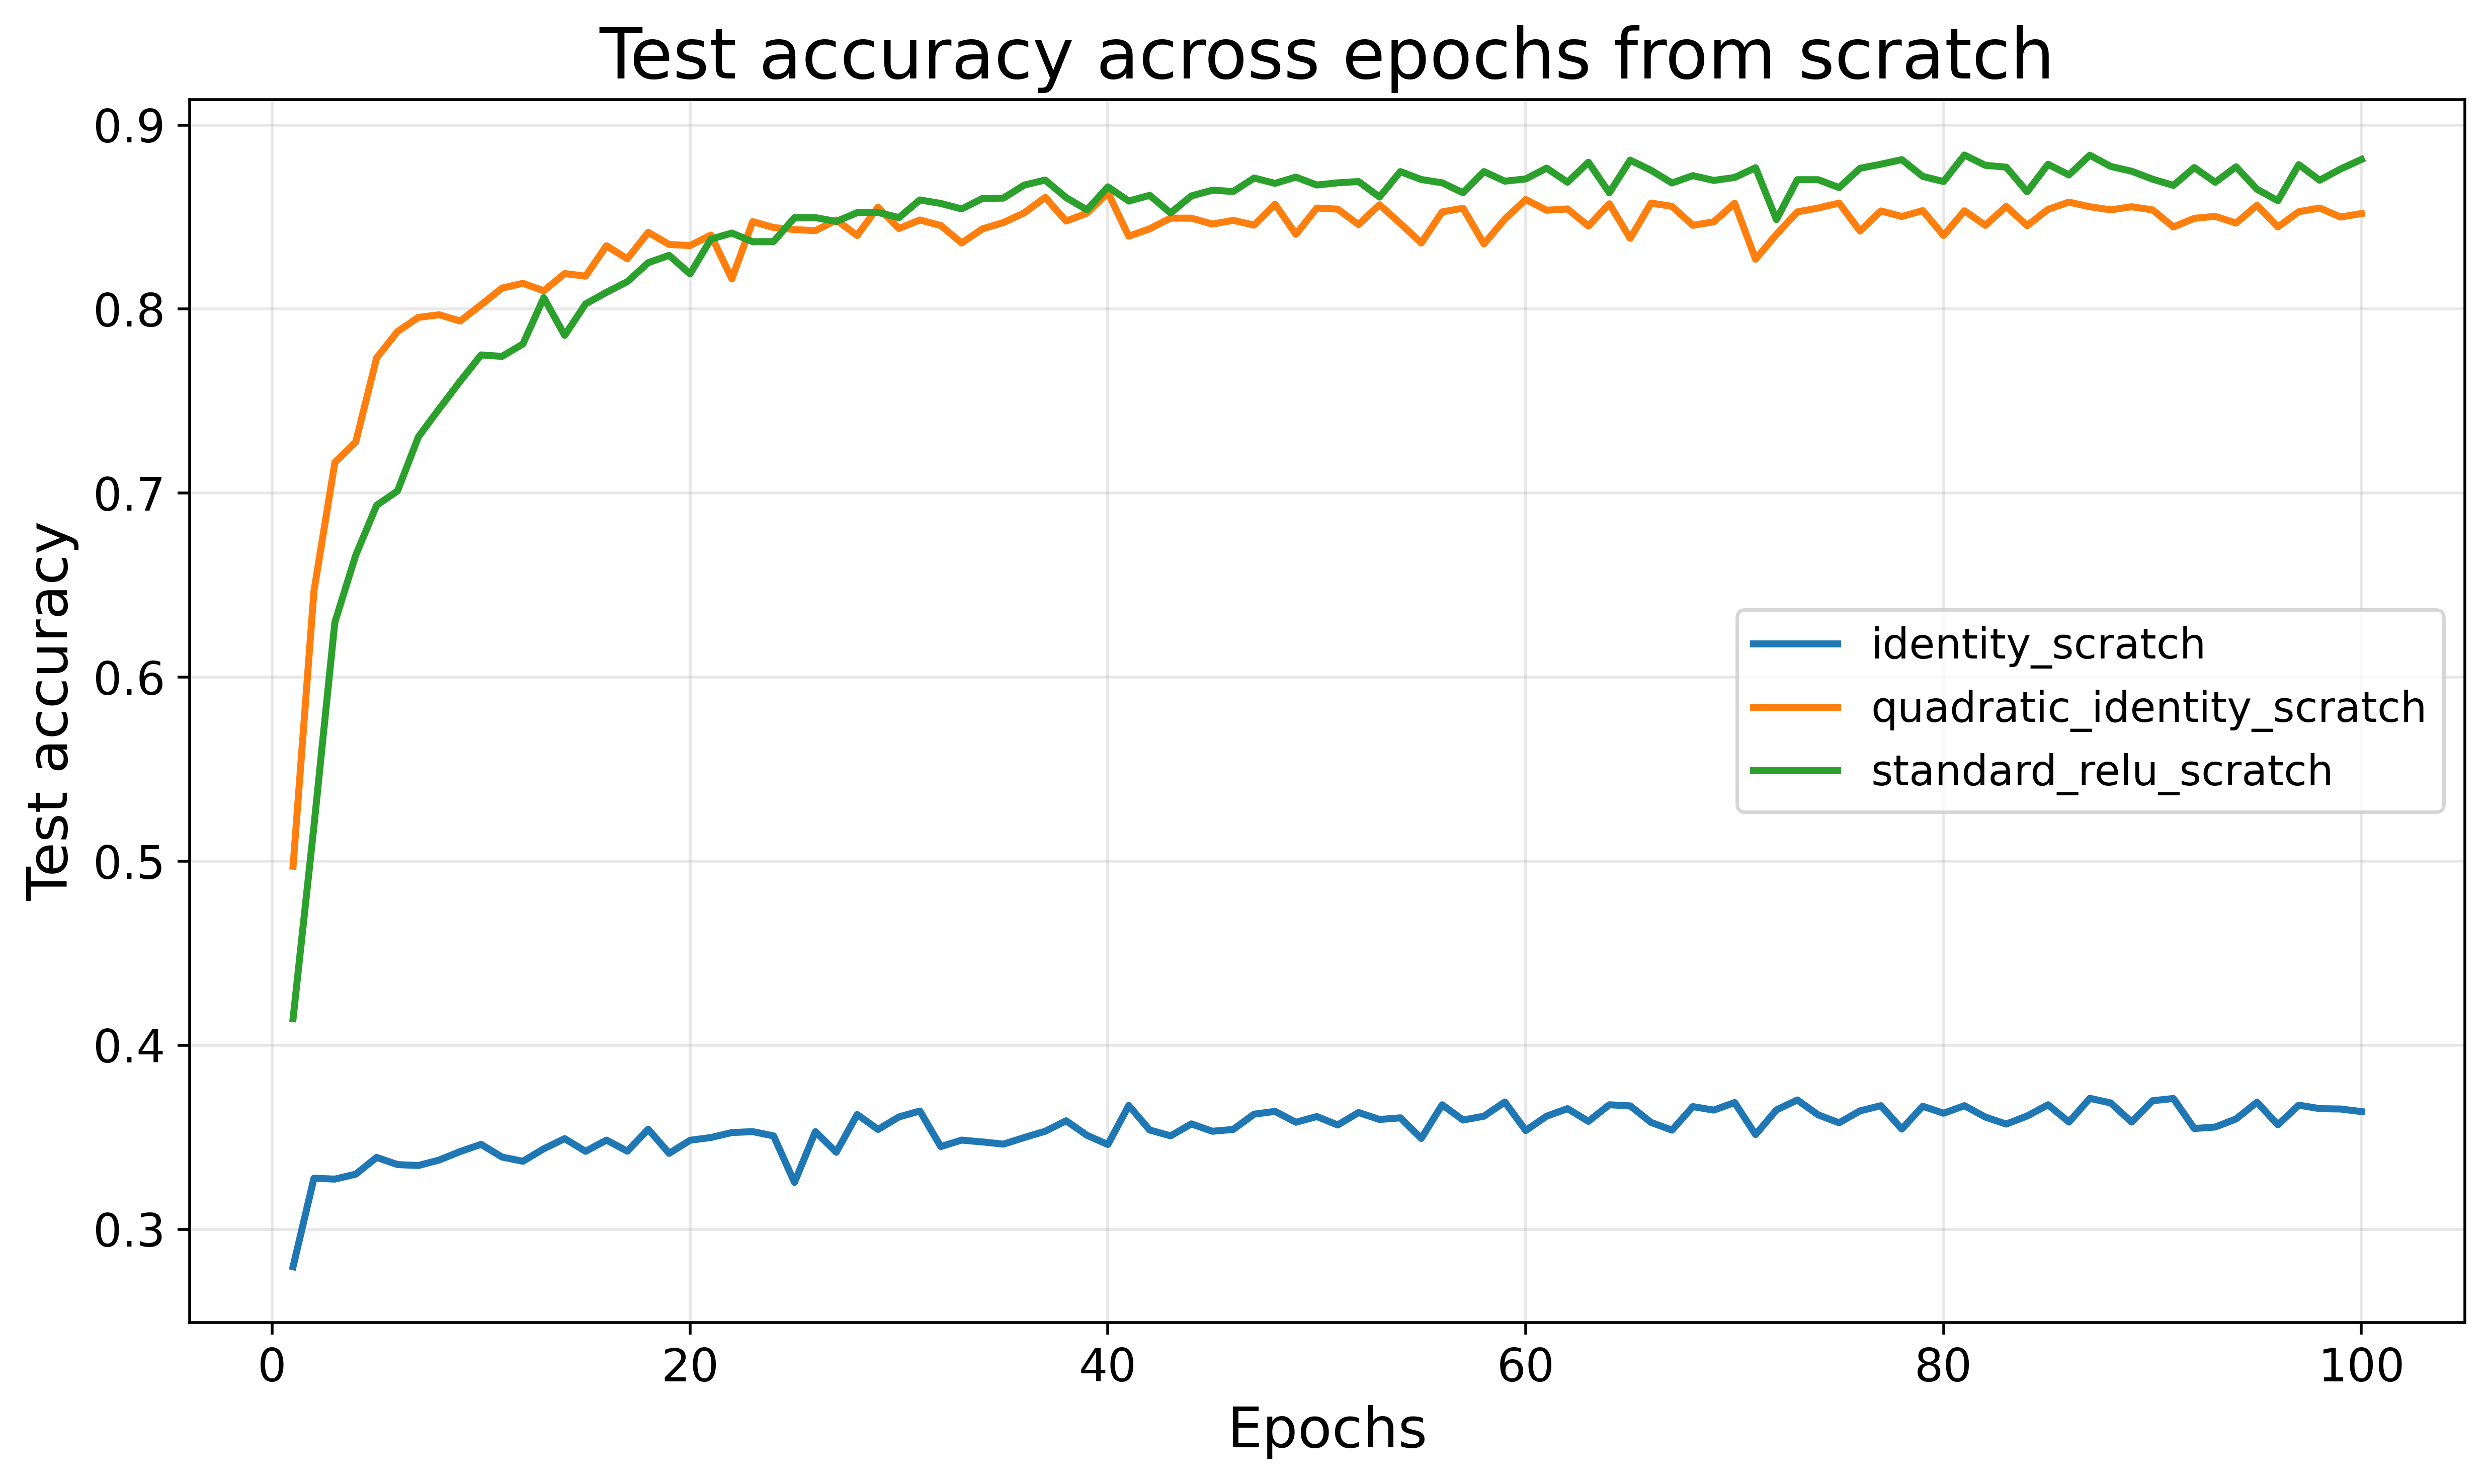

In [5]:
def load_first_json_object(path: Path):
    """Load the first valid JSON object from a file, ignoring accidental trailing text."""
    text = path.read_text()
    decoder = json.JSONDecoder()
    obj, end = decoder.raw_decode(text.lstrip())
    return obj


files = [
    Path("metrics.json"),
    Path("metrics1.json"),
    Path("metrics2.json"),
]

runs = []

for path in files:
    data = load_first_json_object(path)
    runs.append({
        "file": path.name,
        "label": data.get("stage", path.stem),
        "test_acc": data["test_acc"],
    })

plt.figure(figsize=(10, 6), dpi= 500)

for run in runs:
    epochs = range(1, len(run["test_acc"]) + 1)
    plt.plot(
        epochs,
        run["test_acc"],
        label=f'{run["label"]}',
        linewidth = 2
    )

plt.xlabel("Epochs", fontsize = 16)
plt.ylabel("Test accuracy", fontsize = 16)
plt.title("Test accuracy across epochs from scratch", fontsize = 20)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize = 12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

summary = []

for run in runs:
    best_test_acc = max(run["test_acc"])
    best_epoch = run["test_acc"].index(best_test_acc) + 1
    final_test_acc = run["test_acc"][-1]

    summary.append({
        "Model/run": run["label"],
        "Best test accuracy": best_test_acc,
        "Best epoch": best_epoch,
        "Final epoch accuracy": final_test_acc,
    })

df = pd.DataFrame(summary)
df

,Model/run,Best test accuracy,Best epoch,Final epoch accuracy
0,identity_scratch,0.3712,87,0.3640
1,quadratic_identity_scratch,0.8633,40,0.8519
2,standard_relu_scratch,0.8837,81,0.8813
